---
title: "Is jev underpowered?"
date: 2026-09-28
---

[TypeSafe calls Jev the first model in its System One model class](https://docs.typesafe.ai/concepts/system-one), named after Daniel Kahneman's distinction between fast, automatic judgment (System 1) and slower, deliberate reasoning (System 2).  Also, [TypeSafe claims that System One models output calibrated probabilities](https://typesafe.ai/blog/introducing-system-one-models-and-jev). Calibrated against what? [I'm not the first to ask](https://www.alexmolas.com/2026/09/23/jev-cant-be-calibrated.html), but I want to answer a more specific question. Kahneman himself later [admitted that he had placed too much faith in underpowered studies](https://retractionwatch.com/2017/02/20/placed-much-faith-underpowered-studies-nobel-prize-winner-admits-mistakes/). Can Jev give plausible probabilities for a question where published research has produced exaggerated estimates?

For example, does Jev "believe" the widely reported claim that good-looking parents are 36% more likely to have a daughter than a son as their first child? [Gelman and Weakliem](https://sites.stat.columbia.edu/gelman/research/unpublished/power.pdf) trace how this claim grew in analysis and reporting. A regression analysis estimated a statistically non-significant difference of 4.7 percentage points. A selected comparison put the difference at 8 percentage points; a logistic regression estimated 26% lower odds of having a son; and media reports ultimately turned this into the claim that attractive parents were 36% more likely to have a daughter than a son. The study had about 3,000 respondents, but even that sample was too small to reliably detect the effects of less than 1 percentage point considered plausible from prior research.

Let's ask Jev a question using the same beauty-rating scale. We do not provide the original study or identify a particular population.

_An interviewer rates the beauty of a random parent on a scale from 1 to 5. The rating of that parent is X. Is the parent's first child a girl?_

We sample 1,000 ratings uniformly between 1 and 5 and make a separate call to `jev-1.13.0` for each sampled rating. Following [TypeSafe's self-consistency cookbook](https://docs.typesafe.ai/cookbooks/consistency_noul_cookbook), every call contains one question and a fresh, throwaway `uid` in its state. Because the `uid` changes on every call, the inputs are not literally identical. If the answers vary, we cannot tell whether this reflects Jev's inherent predictive variability or sensitivity to the otherwise irrelevant `uid`. Each dot below is the answer from one separate API call:

In [2]:
from dotenv import load_dotenv
from secrets import token_hex
from typesafe_sdk import Noul, TypeSafeClient
import numpy as np

load_dotenv()


def generate_ratings(size: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.choice(np.arange(1, 6), size=size)


def format_question(rating: int) -> str:
    return (
        "An interviewer rates the beauty of a random parent on a scale from 1 to 5. "
        f"The rating of that parent is {rating}. "
        "Is the parent's first child a girl?"
    )


def run_independent_call(
    client: TypeSafeClient, rating: int, sample_index: int, model: str
) -> dict[str, int | float | str]:
    question = Noul(instructions=format_question(rating))
    uid = f"{sample_index}:{token_hex(4)}"
    response = client.system_one(
        state={"uid": uid, "task": "Zero-shot classification"},
        questions={"first_child_girl": question},
        model=model,
    )
    return {
        "sample": sample_index,
        "uid": uid,
        "rating": int(rating),
        "question": question.instructions,
        "girl_probability": response.answers["first_child_girl"].noul,
        "response_model": response.model,
    }

In [3]:
from pathlib import Path
import polars as pl

DATA_PATH = Path("data.csv")
MODEL = "jev-1.13.0"

if DATA_PATH.exists():
    data = pl.read_csv(DATA_PATH)
else:
    ratings = generate_ratings(size=1000, seed=20260928)
    with TypeSafeClient() as client:
        observations = [
            run_independent_call(client, rating, sample_index, MODEL)
            for sample_index, rating in enumerate(ratings)
        ]
    data = pl.DataFrame(observations)
    data.write_csv(DATA_PATH)

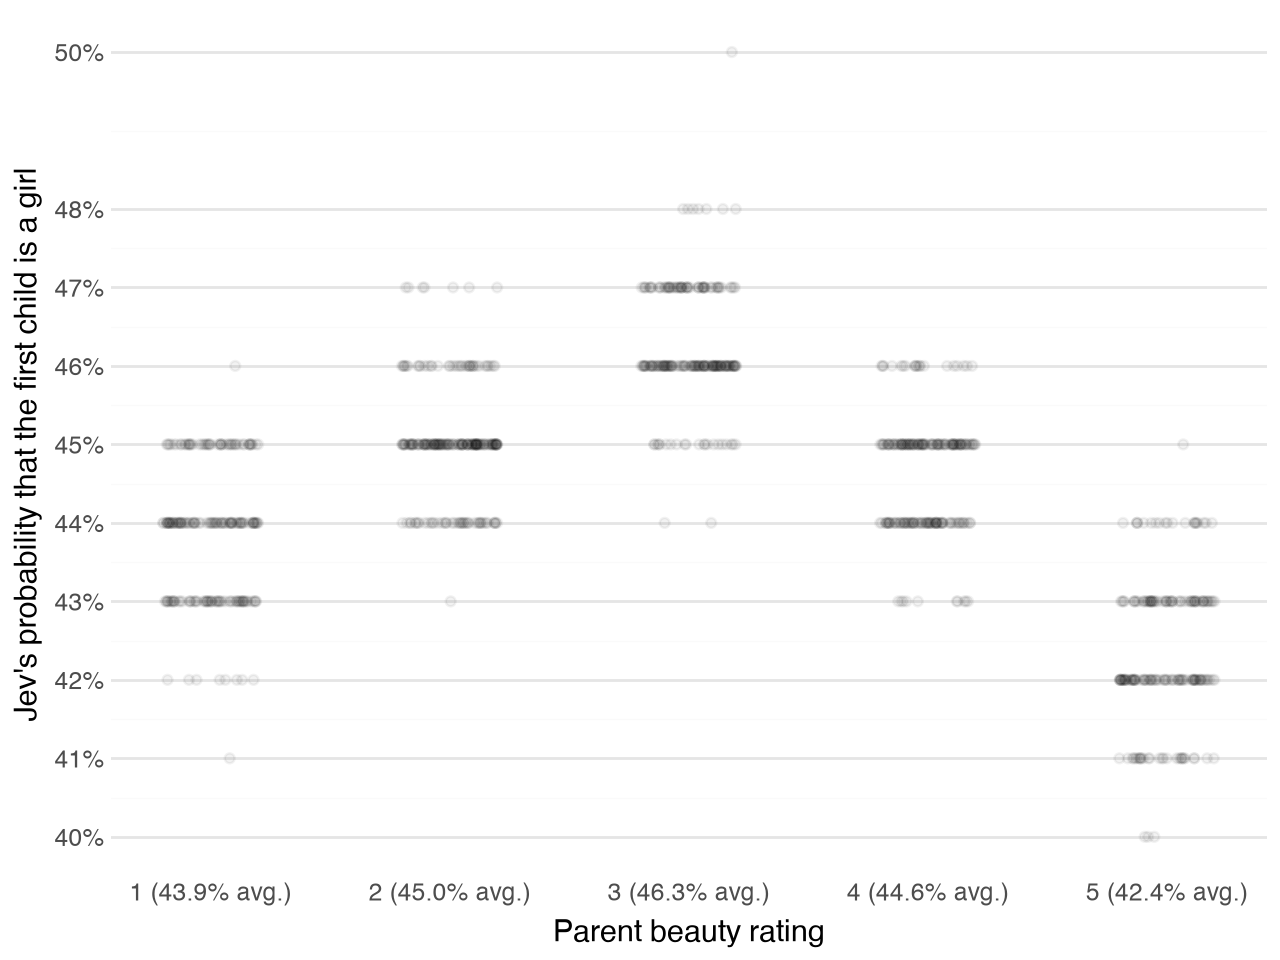

In [5]:
import plotnine as pn

plot_data = (
    data.group_by("rating").agg(pl.col("girl_probability").mean()).sort("rating")
)
rating_breaks = plot_data["rating"].to_list()
rating_labels = [
    f"{rating} ({probability:.1%} avg.)"
    for rating, probability in plot_data.iter_rows()
]
probability_breaks = data["girl_probability"].unique().to_list()

(
    pn.ggplot()
    + pn.aes(x="rating", y="girl_probability")
    + pn.geom_jitter(data=data, alpha=0.05, height=0, width=0.2)
    + pn.scale_x_continuous(breaks=rating_breaks, labels=rating_labels)
    + pn.scale_y_continuous(
        breaks=probability_breaks,
        labels=lambda values: [f"{value:.0%}" for value in values],
    )
    + pn.labs(
        x="Parent beauty rating",
        y="Jev's probability that the first child is a girl",
    )
    + pn.theme_minimal()
    + pn.theme(
        panel_grid_major_x=pn.element_blank(),
        panel_grid_minor_x=pn.element_blank(),
    )
)

Points are jittered horizontally so we can get a better sense of the distribution. The average probabilities for ratings 1 through 5 are 43.9%, 45.0%, 46.3%, 44.6%, and 42.4%. All are below the usual baseline of about 49%.  The largest difference between group averages is 3.9 percentage points, between ratings 3 and 5. The non-monotonic pattern is also odd: the average rises from 43.9% at rating 1 to 46.3% at rating 3, then falls to 42.4% at rating 5. Although the prompt leaves the population unspecified, these values are difficult to reconcile with that baseline and the small effects considered plausible in the literature.

While this experiment does not measure calibration against observed outcomes, it does show that Jev predicts probabilities that are difficult to reconcile with the usual birth-sex baseline and plausible effects of parental attractiveness. What evidence supports treating Jev's probabilities as calibrated on questions like this?